## **Business Understanding**
### **Background**

The stock market plays a crucial role in economic development by enabling companies to raise capital and providing investors with opportunities to grow their wealth. In Kenya, the Nairobi Securities Exchange serves as the primary platform where publicly listed companies trade their shares.

Investors often rely on historical price trends, financial analysis, and market news when making investment decisions. However, predicting stock price movements remains a complex task due to market volatility, investor behavior, and external economic influences.

One of the most actively traded companies on the exchange is Safaricom. Due to its large market capitalization and high trading volume, Safaricom plays a significant role in influencing overall market activity. Analyzing and forecasting its stock price movements can therefore provide useful insights into investment strategies and market dynamics.

With the availability of historical market data and advancements in machine learning techniques, it is now possible to build predictive models that can identify patterns in stock price movements. These models can assist investors and analysts in making more informed decisions by estimating future price trends based on historical data.

### **Market Research**

This section explains:

- how the Nairobi Securities Exchange works
- importance of stock prediction
- importance of Safaricom in the market
- existing prediction methods

The `Nairobi Securities Exchange`(NSE) is the primary securities exchange in Kenya where publicly listed companies trade shares and other financial instruments. The exchange plays a significant role in facilitating investment, capital formation, and economic growth within the country.

Stock prices in financial markets are influenced by a variety of factors including company performance, macroeconomic conditions, investor sentiment, and trading activity. As a result, forecasting stock price movements has become an important area of research in finance and data science.

Among the companies listed on the exchange, `Safaricom` is one of the most actively traded stocks. Due to its large market capitalization and high liquidity, Safaricom frequently accounts for a significant portion of total trading activity in the market. This makes it an important case study for analyzing stock price behavior in the Kenyan market.

In recent years, machine learning and data-driven approaches have been increasingly applied to financial forecasting. Techniques such as regression models, tree-based algorithms, and neural networks have shown potential in identifying hidden patterns within historical financial data. These methods can complement traditional financial analysis by providing predictive insights based on historical trading patterns.

By leveraging historical trading data from the Nairobi Securities Exchange, this project explores how machine learning techniques can be applied to predict stock prices and identify potential investment opportunities within the Kenyan market.

### **Problem Statement**

Predicting stock price movements remains a significant challenge due to the dynamic and unpredictable nature of financial markets. Investors in the Nairobi Securities Exchange often rely on historical price trends and manual analysis when making investment decisions, which may not always capture hidden patterns within large datasets.

Despite the availability of historical trading data, there is limited use of data-driven predictive models specifically focused on stocks listed in the Kenyan market. This creates an opportunity to explore how machine learning techniques can be used to analyze historical stock data and generate reliable price forecasts.

This project seeks to develop a predictive model capable of estimating the next-day closing price of Safaricom using historical trading data. Additionally, the study will extend the analysis to a broader market perspective by applying the model to multiple stocks listed on the Nairobi Securities Exchange in order to identify the top 20 stocks with the highest predicted returns.

### **Objectives**
#### *Main Objective*
To develop a machine learning model that predicts future stock prices using historical trading data from the Nairobi Securities Exchange.

#### *Specific Objectives*
1. To analyze historical trading data of Safaricom stock from 2007 to 2025.
2. To perform exploratory data analysis in order to understand price trends, volatility, and trading patterns..
3. To train and evaluate multiple machine learning models for predicting next-day stock prices.
4. To extend the prediction model to multiple stocks listed on the Nairobi Securities Exchange.
5. To rank stocks based on predicted returns and identify the top 20 potentially high-performing stocks.

### **Stakeholders**

Several stakeholders may benefit from insights generated in this project:
1. Investors and Traders - Individual and institutional investors can use predictive insights to support investment decision-making and identify potential opportunities within the stock market.

2. Financial Analysts - Market analysts can utilize predictive models to complement traditional financial analysis methods when evaluating stock performance.

3. tock Brokerage Firms - Brokerage firms may use predictive insights to provide data-driven recommendations to their clients.

4. Researchers and Data Scientists - This project contributes to the growing field of financial data science by demonstrating how machine learning techniques can be applied to stock market prediction using local market data.

5. The Nairobi Securities Exchange - Insights derived from this analysis may contribute to a deeper understanding of trading patterns and market dynamics within the exchange.

## **Data Understanding**
### **Data Sources**
The dataset used in this project consists of historical stock market trading data from the Nairobi Securities Exchange covering the period `2007` to `OCT 2025`. The data contains daily trading records for multiple companies listed on the exchange.

Each record includes information such as the trading date, stock code, company name, daily price movements, trading volume, and other related indicators.

The dataset was collected in multiple files organized by year. To facilitate analysis, the files are combined into a single dataset that contains all trading records within the study period.

*importing the required libraries and loading the data* 

In [1]:
# Load relevant libraries.
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# Define the data path
DATA_PATH = Path("../data/raw_data")

print(DATA_PATH)

..\data\raw_data


First, we load a sample file to inspect the data. 

In [3]:
# Load the 2007 data into a variable
df_2007 = pd.read_csv(DATA_PATH / "NSE_data_all_stocks_2007.csv")

# Inspect the first 5 rows
df_2007.head()

,DATE,CODE,NAME,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume,Adjust
0,1/2/2007,EGAD,Eaagads,22,57,52,52,52,52,-,-,300,26
1,1/2/2007,KAPC,Kapchorua Tea,111,148,100,100,100,98.5,1.5,1.50%,"7,800",-
2,1/2/2007,KUKZ,Kakuzi,67.5,89,42.5,45,43.5,42.25,1.25,2.87%,"2,700",-
3,1/2/2007,REA,Rea Vipingo Plantations,14.5,23.5,25,26.5,25.5,25.75,-0.25,0.98%,"10,500",-
4,1/2/2007,SASN,Sasini Tea and Coffee,10.5,13.6,140,145,140,141,-1,0.71%,"70,900",23.33


- From this sample, we already note inconsistencies, especially in the column names; there are some that are in uppercase, whereas some are in title case.

- Also, in some columns, we can see that a dash (-) is used, we'll find out why later.

In [4]:
# Inspect the datasets details (nulls, number of columns etc.)
df_2007.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   DATE       10608 non-null  object
 1   CODE       10608 non-null  object
 2   NAME       10585 non-null  object
 3   12m Low    10608 non-null  object
 4   12m High   10608 non-null  object
 5   Day Low    10608 non-null  object
 6   Day High   10608 non-null  object
 7   Day Price  10608 non-null  object
 8   Previous   10608 non-null  object
 9   Change     10608 non-null  object
 10  Change%    10608 non-null  object
 11  Volume     10608 non-null  object
 12  Adjust     10608 non-null  object
dtypes: object(13)
memory usage: 1.1+ MB


From the summary above, the dataset;
- contains missing data in only one column
- all data is stored as objects
- has 13 columns

In [5]:
# Print columns
df_2007.columns

Index(['DATE', 'CODE', 'NAME', '12m Low', '12m High', 'Day Low', 'Day High',
       'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 'Adjust'],
      dtype='object')

#### *Combine All Datasets*
As mentioned ealier, we are combining the datasets under one variable for easy access 

In [6]:
# Find all files in the raw_data folder
files = glob.glob("../data/raw_data/*.csv")

# Ensure all files are found
files

['../data/raw_data\\NSE_data_all_stocks_2007.csv',
 '../data/raw_data\\NSE_data_all_stocks_2008.csv',
 '../data/raw_data\\NSE_data_all_stocks_2009.csv',
 '../data/raw_data\\NSE_data_all_stocks_2010.csv',
 '../data/raw_data\\NSE_data_all_stocks_2011.csv',
 '../data/raw_data\\NSE_data_all_stocks_2012.csv',
 '../data/raw_data\\NSE_data_all_stocks_2013.csv',
 '../data/raw_data\\NSE_data_all_stocks_2014.csv',
 '../data/raw_data\\NSE_data_all_stocks_2015.csv',
 '../data/raw_data\\NSE_data_all_stocks_2016.csv',
 '../data/raw_data\\NSE_data_all_stocks_2017.csv',
 '../data/raw_data\\NSE_data_all_stocks_2018.csv',
 '../data/raw_data\\NSE_data_all_stocks_2019.csv',
 '../data/raw_data\\NSE_data_all_stocks_2020.csv',
 '../data/raw_data\\NSE_data_all_stocks_2021_upto_31dec2021.csv',
 '../data/raw_data\\NSE_data_all_stocks_2022.csv',
 '../data/raw_data\\NSE_data_all_stocks_2023.csv',
 '../data/raw_data\\NSE_data_all_stocks_2024.csv',
 '../data/raw_data\\NSE_data_all_stocks_2025_jan_to_oct.csv']

In [7]:
# Create an empty list
dfs = []

# Loop over every file and read the contents
for file in files:
    df = pd.read_csv(file)

    # Append the dataframes to the empty list, dfs, to create a list of dataframes with no index
    dfs.append(df)

In [8]:
# Concatenate the dataframes to create one dataframe
combined_df = pd.concat(dfs, ignore_index=True)

# Review the first 15 rows
combined_df.head(15)

,DATE,CODE,NAME,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume,Adjust,Date,Adjusted,Code,Name,Adjusted Price
0,1/2/2007,EGAD,Eaagads,22,57,52,52,52,52,-,-,300,26,NaN,NaN,NaN,NaN,NaN
1,1/2/2007,KAPC,Kapchorua Tea,111,148,100,100,100,98.5,1.5,1.50%,"7,800",-,NaN,NaN,NaN,NaN,NaN
2,1/2/2007,KUKZ,Kakuzi,67.5,89,42.5,45,43.5,42.25,1.25,2.87%,"2,700",-,NaN,NaN,NaN,NaN,NaN
3,1/2/2007,REA,Rea Vipingo Plantations,14.5,23.5,25,26.5,25.5,25.75,-0.25,0.98%,"10,500",-,NaN,NaN,NaN,NaN,NaN
4,1/2/2007,SASN,Sasini Tea and Coffee,10.5,13.6,140,145,140,141,-1,0.71%,"70,900",23.33,NaN,NaN,NaN,NaN,NaN
5,1/2/2007,UTK,Unilever Tea Kenya,45,45,80,82,81,81.5,-0.5,0.62%,"1,000",-,NaN,NaN,NaN,NaN,NaN
6,1/2/2007,WTK,Williamson Tea Kenya,180,290,120,120,120,118,2,1.67%,"10,000",-,NaN,NaN,NaN,NaN,NaN
7,1/2/2007,C&G,Car and General (K),21,29,50,50,50,50,-,-,"66,700",33.33,NaN,NaN,NaN,NaN,NaN
8,1/2/2007,CMC,CMC Holdings,13.5,13.5,173,193,188,173,15,7.98%,"36,200",15.67,NaN,NaN,NaN,NaN,NaN
9,1/2/2007,FIRE,Sameer Africa,3.4,5.95,22.5,26,24.75,24,0.75,3.03%,"54,800",-,NaN,NaN,NaN,NaN,NaN


In [9]:
# Review the last 15 rows
combined_df.tail(15)

,DATE,CODE,NAME,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume,Adjust,Date,Adjusted,Code,Name,Adjusted Price
300990,NaN,NaN,NaN,0.27,0.27,0.27,0.27,0.27,0.27,-,-,-,NaN,31-Oct-25,NaN,MSC,Mumias Sugar Company Ltd,-
300991,NaN,NaN,NaN,5.8,9.0,7.28,8.0,7.46,8.06,-0.6,-7.44%,6820,NaN,31-Oct-25,NaN,SKL,Shri Krishana Overseas Plc,-
300992,NaN,NaN,NaN,14.4,28.25,24.5,25.0,24.65,24.7,-0.05,-0.20%,1569,NaN,31-Oct-25,NaN,UNGA,Unga Group Ltd,-
300993,NaN,NaN,NaN,14.1,31.0,29.6,30.7,30.25,29.55,0.7,2.37%,3051822,NaN,31-Oct-25,NaN,SCOM,Safaricom Plc,-
300994,NaN,NaN,NaN,20.0,20.0,20.0,20.0,20.0,20,-,-,-,NaN,31-Oct-25,NaN,LAPR,Laptrust Imara Income-REIT,-
300995,NaN,NaN,NaN,3000.0,9800.0,4840.0,5175.0,4910.0,4835,75,1.55%,539,NaN,31-Oct-25,NaN,GLD,ABSA NewGold ETF,-
300996,NaN,NaN,NaN,755.0,1000.0,854.0,857.0,855.0,857,-2,-0.23%,27,NaN,31-Oct-25,NaN,SMWF,Satrix MSCI World Feeder ETF,-
300997,NaN,NaN,NaN,1170.1,1934.23,1910.77,1910.77,1910.77,1877.52,33.25,1.77%,-,NaN,31-Oct-25,NaN,^N10I,NSE 10-Share Index,-
300998,NaN,NaN,NaN,1823.17,3153.39,3116.69,3116.69,3116.69,3090.7,25.99,0.84%,-,NaN,31-Oct-25,NaN,^N20I,NSE 20-Share Index,-
300999,NaN,NaN,NaN,3063.32,5052.98,4998.39,4998.39,4998.39,4900.89,97.5,1.99%,-,NaN,31-Oct-25,NaN,^N25I,NSE 25-Share Index,-


In [10]:
# Turn it into a CSV file
combined_df.to_csv("../data/raw_data/processed/NSE_data_all_stocks_2007-2025.csv", index=False)

### **Data Description**
Here, we will be examining the data structure, such as record counts and field types (numerical, categorical, text).

#### *Shape*

In [11]:
# Shape of the dataset
print("Rows, Columns:", combined_df.shape)

Rows, Columns: (301005, 18)


#### *Columns*

In [12]:
combined_df.columns

Index(['DATE', 'CODE', 'NAME', '12m Low', '12m High', 'Day Low', 'Day High',
       'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 'Adjust',
       'Date', 'Adjusted', 'Code', 'Name', 'Adjusted Price'],
      dtype='object')

#### *Data Summary*

In [13]:
# Data types and non-null values
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301005 entries, 0 to 301004
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   DATE            223107 non-null  object
 1   CODE            233690 non-null  object
 2   NAME            233642 non-null  object
 3   12m Low         301003 non-null  object
 4   12m High        301003 non-null  object
 5   Day Low         301003 non-null  object
 6   Day High        301003 non-null  object
 7   Day Price       301003 non-null  object
 8   Previous        301003 non-null  object
 9   Change          301003 non-null  object
 10  Change%         301003 non-null  object
 11  Volume          301003 non-null  object
 12  Adjust          223107 non-null  object
 13  Date            77896 non-null   object
 14  Adjusted        10583 non-null   object
 15  Code            67313 non-null   object
 16  Name            67313 non-null   object
 17  Adjusted Price  67313 non-nul

From the summary above, we note a lot of differences from our sample data;
- Instead of 13 columns, we have 22.
- We now have 3 data types; float, object and string.
- There are different columns that have the same name but written differently.
- Also, only 9 out of the 22 columns seem complete, an issue that might have been brought about by the inconsistent naming of columns.

#### *Statistical Inspection*

In [14]:
# Summary stats for numerical columns
combined_df.describe()

,DATE,CODE,NAME,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume,Adjust,Date,Adjusted,Code,Name,Adjusted Price
count,223107,233690,233642,301003,301003,301003,301003,301003,301003,301003,301003,301003,223107,77896,10583,67313,67313,67313
unique,3491,99,143,903,987,23058,23058,23967,21596,5960,2353,31270,3905,1195,1063,79,81,45
top,24-Mar-17,KEGN,NSE 20-Share Index,4,55.5,5.5,5.5,5.5,5.5,-,-,-,-,31-Oct-25,-,EGAD,Eaagads Ltd,-
freq,138,3744,3645,5689,3848,2968,2909,2721,2738,111261,111368,66398,189965,75,6262,946,946,67254


In [15]:
# Check unique values for each column (useful for categorical vars)
combined_df.nunique()

DATE               3491
CODE                 99
NAME                143
12m Low             903
12m High            987
Day Low           23058
Day High          23058
Day Price         23967
Previous          21596
Change             5960
Change%            2353
Volume            31270
Adjust             3905
Date               1195
Adjusted           1063
Code                 79
Name                 81
Adjusted Price       45
dtype: int64

### **Data Quality Assessment** 
We wiil be identifying missing values, outliers, noise, and potential biases that might affect modeling in the future.

#### *Missing values*

In [16]:
# Total and percent missing
missing = combined_df.isnull().sum()
missing_percent = (missing / len(combined_df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing, 'Percent': missing_percent})
missing_df[missing_df['Missing Values'] > 0]

,Missing Values,Percent
DATE,77898,25.879304
CODE,67315,22.363416
NAME,67363,22.379362
12m Low,2,0.000664
12m High,2,0.000664
Day Low,2,0.000664
Day High,2,0.000664
Day Price,2,0.000664
Previous,2,0.000664
Change,2,0.000664


- As mentioned earlier, the merged dataset contains a lot of missing values, probably brough about by the different naming conventions used in the different datasets merged.

#### *Duplicates*

In [17]:
# Check duplicates
combined_df.duplicated().sum()

np.int64(89)

- The dataset contains 89 duplicate records

#### *Data Integrity Issues*
According to [a Gartner Survey](https://www.gartner.com/en/insights), data issues, including inaccuracies, incompleteness, duplication, and inconsistency, severely hinder business insights, causing an estimated $12.9 million in annual losses.

In our merged dataset, we have identified the following issues.

|No. | Issue |
| ------ | ------- |
| 1. | Inconsistent column names |
| 2. | Missing values |
| 3. | Duplicates |
| 4. | Wrong data formats |

## **Data Cleaning**

Data cleaning is a critical step in the data science workflow that involves identifying and correcting errors, inconsistencies, and inaccuracies in a dataset. Raw data collected from different sources or across long time periods often contains issues such as missing values, inconsistent column naming, duplicate variables, incorrect data formats, and redundant information. If these issues are not addressed, they can negatively affect the quality of analysis and the performance of predictive models.

In the context of this project, the Nairobi Securities Exchange (NSE) dataset was compiled from multiple yearly records spanning from 2007 to 2025. Because the data originates from different time periods and potentially different reporting formats, several inconsistencies were observed during the data understanding phase. These include variations in column naming conventions (for example, `DATE` vs `Date`), duplicate columns representing the same variable, automatically generated index columns, and missing values resulting from the merging process.

The objective of the data cleaning stage is therefore to transform the raw merged dataset into a structured and consistent format suitable for analysis and modeling. The key steps performed in this phase include:

- Resolving inconsistencies in column names.
- Merging duplicate columns representing the same variables.
- Removing redundant or unnecessary columns.
- Standardizing the structure and ordering of dataset columns.
- Preparing the dataset for further preprocessing steps such as data type conversion and exploratory data analysis.

By completing these cleaning steps, the dataset becomes more reliable and suitable for downstream tasks including exploratory analysis, feature engineering, and the development of machine learning models for stock price prediction.

### **Handling Column Name Inconsistencies**

After merging the NSE datasets from multiple years, several duplicated columns were identified. These duplicates occurred because different datasets used different capitalization styles for the same variables.

Examples include:

| Column Version 1 | Column Version 2 |
|------------------|------------------|
| DATE | Date |
| CODE | Code |
| NAME | Name |
| Adjust | Adjusted |
| Adjusted Price | Adjust |

Because pandas treats column names as case-sensitive, these columns were interpreted as separate variables during the merge process. As a result, some rows contain values in one column while the corresponding duplicate column contains missing values.

#### **Cleaning Strategy**

To resolve this issue:
1. Merge duplicated columns representing the same variable.
2. Fill missing values in one column using values from the other column.
3. Retain a single standardized column name.
4. Remove redundant columns after merging.

This ensures the dataset maintains a consistent schema across all observations.

In [18]:
combined_df.columns

Index(['DATE', 'CODE', 'NAME', '12m Low', '12m High', 'Day Low', 'Day High',
       'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 'Adjust',
       'Date', 'Adjusted', 'Code', 'Name', 'Adjusted Price'],
      dtype='object')

##### *`date`*

In [19]:
# combine Date and DATE columns into one column called date
combined_df['date'] = combined_df['DATE'].fillna(combined_df['Date'])

In [20]:
# check the new date column for nulls
combined_df['date'].isna().sum()

np.int64(2)

##### *`code`*

In [21]:
# combine Code and CODE columds
combined_df['code'] = combined_df['CODE'].fillna(combined_df['Code'])

In [22]:
#Check the code colums for nulls
combined_df['code'].isna().sum()

np.int64(2)

##### *`name`*

In [23]:
# combine name and NAME columns
combined_df['name'] = combined_df['NAME'].fillna(combined_df['Name'])

In [24]:
# check the name column for nulls
combined_df['name'].isna().sum()

np.int64(50)

##### *`adjusted_price`*

In [25]:
# combine Adjusted Price, Adjust and Adjusted columns into one column called adjusted_price
combined_df['adjusted_price'] = combined_df['Adjusted Price'].fillna(combined_df['Adjust'])
combined_df['adjusted_price'] = combined_df['adjusted_price'].fillna(combined_df['Adjusted'])

In [26]:
# check the adjusted_prices column for nulls
combined_df['adjusted_price'].isna().sum()

np.int64(2)

In [27]:
# Confirm if all added columns are there.
combined_df.columns

Index(['DATE', 'CODE', 'NAME', '12m Low', '12m High', 'Day Low', 'Day High',
       'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 'Adjust',
       'Date', 'Adjusted', 'Code', 'Name', 'Adjusted Price', 'date', 'code',
       'name', 'adjusted_price'],
      dtype='object')

In [28]:
# drop the original columns that have been combined into new columns
combined_df = combined_df.drop(columns=[
'DATE','Date',
'CODE','Code',
'NAME','Name',
'Adjust','Adjusted','Adjusted Price'
])

In [29]:
# Confirm if all column issues are sorted.
combined_df.columns

Index(['12m Low', '12m High', 'Day Low', 'Day High', 'Day Price', 'Previous',
       'Change', 'Change%', 'Volume', 'date', 'code', 'name',
       'adjusted_price'],
      dtype='object')

In [30]:
# Review the changes.
combined_df.head()

,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume,date,code,name,adjusted_price
0,22,57,52,52,52,52,-,-,300,1/2/2007,EGAD,Eaagads,26
1,111,148,100,100,100,98.5,1.5,1.50%,"7,800",1/2/2007,KAPC,Kapchorua Tea,-
2,67.5,89,42.5,45,43.5,42.25,1.25,2.87%,"2,700",1/2/2007,KUKZ,Kakuzi,-
3,14.5,23.5,25,26.5,25.5,25.75,-0.25,0.98%,"10,500",1/2/2007,REA,Rea Vipingo Plantations,-
4,10.5,13.6,140,145,140,141,-1,0.71%,"70,900",1/2/2007,SASN,Sasini Tea and Coffee,23.33


### **Column Cleanup and Standardization**

After merging and consolidating duplicate columns, the dataset still contained unnecessary index columns (`Unnamed: 0` and `Unnamed: 0.1`). These columns were automatically generated during previous CSV exports and do not contain meaningful analytical information.

To prepare the dataset for analysis, the following steps were performed:

1. Remove redundant index columns (`Unnamed: 0`, `Unnamed: 0.1`).
2. Standardize column names to a consistent naming format.
3. Reorder the columns to match the desired schema for analysis.

The final dataset structure will be:

Date, Code, Name, 12m Low, 12m High, Day Low, Day High, Day Price, Previous, Change, Change%, Volume, Adjusted Price

This structure ensures clarity and consistency before proceeding to data type corrections and exploratory analysis.

#### *Drop redundant columns*

In [31]:
# Drop redundant index columns
combined_df = combined_df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1', 'unnamed:_0.3', 'unnamed:_0.2'], errors='ignore')

#### *Standardize column names*

In [32]:
# standardize column names to lowercase and replace spaces with underscores
combined_df.columns = combined_df.columns.str.lower().str.replace(' ', '_')

In [33]:
# Review changes.
combined_df.columns

Index(['12m_low', '12m_high', 'day_low', 'day_high', 'day_price', 'previous',
       'change', 'change%', 'volume', 'date', 'code', 'name',
       'adjusted_price'],
      dtype='object')

#### *Restructure the dataset*

In [34]:
combined_df = combined_df[[
'date',
'code',
'name',
'12m_low',
'12m_high',
'day_low',
'day_high',
'day_price',
'previous',
'change',
'change%',
'volume',
'adjusted_price'
]]

combined_df.head()

,date,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price
0,1/2/2007,EGAD,Eaagads,22,57,52,52,52,52,-,-,300,26
1,1/2/2007,KAPC,Kapchorua Tea,111,148,100,100,100,98.5,1.5,1.50%,"7,800",-
2,1/2/2007,KUKZ,Kakuzi,67.5,89,42.5,45,43.5,42.25,1.25,2.87%,"2,700",-
3,1/2/2007,REA,Rea Vipingo Plantations,14.5,23.5,25,26.5,25.5,25.75,-0.25,0.98%,"10,500",-
4,1/2/2007,SASN,Sasini Tea and Coffee,10.5,13.6,140,145,140,141,-1,0.71%,"70,900",23.33


check for missing data after the merge

In [35]:
# Total and percent missing
missing_merged = combined_df.isnull().sum()
missing_percent = (missing_merged / len(combined_df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_merged, 'Percent': missing_percent})
missing_df[missing_df['Missing Values'] > 0]

,Missing Values,Percent
date,2,0.000664
code,2,0.000664
name,50,0.016611
12m_low,2,0.000664
12m_high,2,0.000664
day_low,2,0.000664
day_high,2,0.000664
day_price,2,0.000664
previous,2,0.000664
change,2,0.000664


In [36]:
# generate a copy of a final dataset
combined_df.to_csv("../data/raw_data/processed/nse_final_dataset.csv", index=False)

In [37]:
combined_df.describe()

,date,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price
count,301003,301003,300955,301003,301003,301003,301003,301003,301003,301003,301003,301003,301003
unique,4686,107,154,903,987,23058,23058,23967,21596,5960,2353,31270,4031
top,24-Mar-17,EVRD,NSE 20-Share Index,4,55.5,5.5,5.5,5.5,5.5,-,-,-,-
freq,138,4690,4486,5689,3848,2968,2909,2721,2738,111261,111368,66398,263481


### **Data Type Correction**

After completing the initial data cleaning process and producing a consolidated dataset, the next step involves correcting the data types of several variables. When datasets are imported from CSV files, columns containing numeric values may sometimes be interpreted as text due to the presence of formatting characters such as commas or percentage signs.

For example, columns such as **Volume** may contain values formatted with commas (e.g., "7,800"), while **Change%** includes percentage symbols (e.g., "1.50%"). Additionally, the **Date** column is initially stored as a string rather than a datetime object.

These formatting issues prevent proper numerical analysis and must therefore be corrected. In this stage, the dataset will be prepared for analysis by:

- Converting the **Date** column to a datetime format.
- Removing commas from the **Volume** column and converting it to numeric.
- Removing percentage symbols from **Change%** and converting it to a numeric value.
- Ensuring all price-related columns are stored as numeric data types.

Correcting these data types ensures that the dataset can be used effectively for exploratory analysis and machine learning models.

Using the `nse_final_dataset.csv` to continue with data cleaning

In [38]:
# load the final dataset to confirm it was saved correctly
cleaning_df = pd.read_csv("../data/raw_data/processed/nse_final_dataset.csv")

cleaning_df.head()

,date,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price
0,1/2/2007,EGAD,Eaagads,22,57,52,52,52,52,-,-,300,26
1,1/2/2007,KAPC,Kapchorua Tea,111,148,100,100,100,98.5,1.5,1.50%,"7,800",-
2,1/2/2007,KUKZ,Kakuzi,67.5,89,42.5,45,43.5,42.25,1.25,2.87%,"2,700",-
3,1/2/2007,REA,Rea Vipingo Plantations,14.5,23.5,25,26.5,25.5,25.75,-0.25,0.98%,"10,500",-
4,1/2/2007,SASN,Sasini Tea and Coffee,10.5,13.6,140,145,140,141,-1,0.71%,"70,900",23.33


In [39]:
# check current data types
cleaning_df.dtypes

date              object
code              object
name              object
12m_low           object
12m_high          object
day_low           object
day_high          object
day_price         object
previous          object
change            object
change%           object
volume            object
adjusted_price    object
dtype: object

After loading the cleaning dataset, all columns were interpreted as strings (`str`). This commonly occurs when importing data from CSV files that contain formatting characters such as commas, percentage signs, or placeholder symbols (e.g., "-").

For instance:
- The **Volume, 12m_low, 12m_high, day_low, day_high, day_price, etc.** column contains comma-separated values such as "7,800".
- The **Change%** column includes percentage symbols such as "1.50%".
- Some numeric columns may contain "-" to indicate missing values.

Because machine learning models and statistical analysis require numeric data types, these columns must be converted to their appropriate formats.

The following transformations will be applied:

- Convert **Date** from string to datetime.
- Remove commas from **Volume, 12m_low, 12m_high, day_low, day_high, day_price, etc.** and convert it to a numeric value.
- Remove the `%` symbol from **Change%** and convert it to a float.
- Convert all price-related columns to numeric values.
- Replace invalid placeholders (e.g., "-") with 0, this is because the dash in stock market doesn't necessarily mean the data is missing. For example, in `change` the dash migh mean 0, there was no change in prices during that day.

In [40]:
cleaning_df.tail(15)

,date,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price
300990,31-Oct-25,MSC,Mumias Sugar Company Ltd,0.27,0.27,0.27,0.27,0.27,0.27,-,-,-,-
300991,31-Oct-25,SKL,Shri Krishana Overseas Plc,5.8,9.0,7.28,8.0,7.46,8.06,-0.6,-7.44%,6820,-
300992,31-Oct-25,UNGA,Unga Group Ltd,14.4,28.25,24.5,25.0,24.65,24.7,-0.05,-0.20%,1569,-
300993,31-Oct-25,SCOM,Safaricom Plc,14.1,31.0,29.6,30.7,30.25,29.55,0.7,2.37%,3051822,-
300994,31-Oct-25,LAPR,Laptrust Imara Income-REIT,20.0,20.0,20.0,20.0,20.0,20,-,-,-,-
300995,31-Oct-25,GLD,ABSA NewGold ETF,3000.0,9800.0,4840.0,5175.0,4910.0,4835,75,1.55%,539,-
300996,31-Oct-25,SMWF,Satrix MSCI World Feeder ETF,755.0,1000.0,854.0,857.0,855.0,857,-2,-0.23%,27,-
300997,31-Oct-25,^N10I,NSE 10-Share Index,1170.1,1934.23,1910.77,1910.77,1910.77,1877.52,33.25,1.77%,-,-
300998,31-Oct-25,^N20I,NSE 20-Share Index,1823.17,3153.39,3116.69,3116.69,3116.69,3090.7,25.99,0.84%,-,-
300999,31-Oct-25,^N25I,NSE 25-Share Index,3063.32,5052.98,4998.39,4998.39,4998.39,4900.89,97.5,1.99%,-,-


- As seen above, we see that in most cases where we have `-` in the `change` column, there is no chaneg in `day_price` and `previous`.

- Also, with no change in price, normally the volume also remains at 0, meaning that no trades were done that day. However, we also have instances where there's some changes in price but the row has `-` in the `volume` column, this as also seen in the table above, is mostly when the company is an index. Indices cannot have volume in the traditional sense because they are not actual, traded assets; they are merely mathematical calculations representing the weighted average price of a group of stocks. Unlike stocks, which represent ownership in a company that can be bought and sold, you cannot trade the index directly. 

In [41]:
cleaning_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301005 entries, 0 to 301004
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   date            301003 non-null  object
 1   code            301003 non-null  object
 2   name            300955 non-null  object
 3   12m_low         301003 non-null  object
 4   12m_high        301003 non-null  object
 5   day_low         301003 non-null  object
 6   day_high        301003 non-null  object
 7   day_price       301003 non-null  object
 8   previous        301003 non-null  object
 9   change          301003 non-null  object
 10  change%         301003 non-null  object
 11  volume          301003 non-null  object
 12  adjusted_price  301003 non-null  object
dtypes: object(13)
memory usage: 29.9+ MB


#### *Correcting Price columns*
So far, all the columns have values stored as `object`. Here, we will be trying to clean the data so that it will be ready to be coverted to the right datatypes.

In the next cell, we are writing a code that;
- Strips whitespace and invisible characters from all columns.
- Removes commas, so numbers like 1,234 become 1234.
- Replaces `-` with 0, which is safe for volume, change, and %change.
- Converts all columns to numeric (float), so your models won’t break.
- Keeps all rows, only truly invalid data becomes NaN.

In [42]:
# List of columns to clean
price_cols = ['12m_low', '12m_high', 'day_low', 'day_high', 'day_price', 
              'previous', 'change', 'change%', 'volume']

# Ensure all are strings
cleaning_df[price_cols] = cleaning_df[price_cols].astype(str)

# Remove common unwanted characters
for col in price_cols:
    cleaning_df[col] = cleaning_df[col].str.replace(',','')       # remove commas
    cleaning_df[col] = cleaning_df[col].str.replace('\xa0','', regex=False)  # remove non-breaking spaces
    cleaning_df[col] = cleaning_df[col].str.strip()              # remove leading/trailing spaces
    cleaning_df[col] = cleaning_df[col].replace('-', '0')        # replace '-' with 0
    cleaning_df[col] = cleaning_df[col].str.replace('%', '', regex=True)

# Convert to numeric
cleaning_df[price_cols] = cleaning_df[price_cols].apply(pd.to_numeric, errors='coerce')

# Optional sanity check
print(cleaning_df[price_cols].dtypes)

12m_low      float64
12m_high     float64
day_low      float64
day_high     float64
day_price    float64
previous     float64
change       float64
change%      float64
volume       float64
dtype: object


In [43]:
# Ensure no nulls arise
cleaning_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301005 entries, 0 to 301004
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   date            301003 non-null  object 
 1   code            301003 non-null  object 
 2   name            300955 non-null  object 
 3   12m_low         301003 non-null  float64
 4   12m_high        301003 non-null  float64
 5   day_low         301003 non-null  float64
 6   day_high        301003 non-null  float64
 7   day_price       301003 non-null  float64
 8   previous        301003 non-null  float64
 9   change          301003 non-null  float64
 10  change%         301003 non-null  float64
 11  volume          301003 non-null  float64
 12  adjusted_price  301003 non-null  object 
dtypes: float64(9), object(4)
memory usage: 29.9+ MB


- We have changed the price columns' data type from object to float.
- We have also replaced the dash (-) with 0, following the stock market's reasoning, all except for the `adjusted_price`

#### *Correcting the Date column*

In [44]:
# Inspect the date column
cleaning_df['date']

0          1/2/2007
1          1/2/2007
2          1/2/2007
3          1/2/2007
4          1/2/2007
            ...    
301000    31-Oct-25
301001    31-Oct-25
301002    31-Oct-25
301003    31-Oct-25
301004    31-Oct-25
Name: date, Length: 301005, dtype: object

In [45]:
# Inspecting all the date formats
cleaning_df['date'].astype(str).str.strip().unique()

array(['1/2/2007', '1/3/2007', '1/4/2007', ..., '29-Oct-25', '30-Oct-25',
       '31-Oct-25'], dtype=object)

- The date column contains 2 date formats; 
   - '1/4/2007'
   - '30-Oct-25'
- First we are going to strip the column of any spaces, or any other things.

In [46]:
# Create a testing date column
cleaning_df['date_test'] = cleaning_df['date'].astype(str).str.strip()

In [47]:
# Changing format 1 to datetime
date1 = pd.to_datetime(cleaning_df['date_test'], format= '%d-%b-%y', errors='coerce')

In [48]:
# Changing format 2 to datetime
date2 = pd.to_datetime(cleaning_df['date_test'], format= '%m/%d/%Y', errors='coerce')

In [49]:
# Creating a cleaned column filling it with cleaned dates from format 1 and format 2
cleaning_df['date_parsed'] = date1.fillna(date2) # type: ignore

In [50]:
# Checking for any missing values
cleaning_df['date_parsed'].isna().sum()

np.int64(2)

- We have found 2 missing dates, in the next cell we are inspecting these.

In [51]:
# Filter the date_parsed column to get the null rows
problem_dates = cleaning_df[cleaning_df['date_parsed'].isna()]

# Review the problem dates
problem_dates

,date,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price,date_test,date_parsed
112088,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan,NaT
179906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan,NaT


- The null dates are null all through the other columns as well.

In [52]:
cleaning_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301005 entries, 0 to 301004
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date            301003 non-null  object        
 1   code            301003 non-null  object        
 2   name            300955 non-null  object        
 3   12m_low         301003 non-null  float64       
 4   12m_high        301003 non-null  float64       
 5   day_low         301003 non-null  float64       
 6   day_high        301003 non-null  float64       
 7   day_price       301003 non-null  float64       
 8   previous        301003 non-null  float64       
 9   change          301003 non-null  float64       
 10  change%         301003 non-null  float64       
 11  volume          301003 non-null  float64       
 12  adjusted_price  301003 non-null  object        
 13  date_test       301005 non-null  object        
 14  date_parsed     301003 non-null  dat

In [53]:
# Drop redundant columns
cleaning_df = cleaning_df.drop(columns=['date', 'date_test'])

### **Dropping Null Values**
To drop null values, we are using `.dropna` but specifying the how to `all`. This is important because if we drop all null values, we lose valuable data from the `name` column as it contains several null values.

The reason we don't drop these values is because in our modeling section, we will actually be using the `code` column, hence the missing values from the `name` column will have no effect whatsoever.

In [54]:
# drop null rows
cleaning_df = cleaning_df.dropna(how= 'all')

In [55]:
# Review changes
cleaning_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 301003 entries, 0 to 301004
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   code            301003 non-null  object        
 1   name            300955 non-null  object        
 2   12m_low         301003 non-null  float64       
 3   12m_high        301003 non-null  float64       
 4   day_low         301003 non-null  float64       
 5   day_high        301003 non-null  float64       
 6   day_price       301003 non-null  float64       
 7   previous        301003 non-null  float64       
 8   change          301003 non-null  float64       
 9   change%         301003 non-null  float64       
 10  volume          301003 non-null  float64       
 11  adjusted_price  301003 non-null  object        
 12  date_parsed     301003 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(9), object(3)
memory usage: 32.2+ MB


In [56]:
# save the cleaned dataset which will be ready for further analysis
cleaning_df.to_csv("../data/raw_data/processed/nse_analysis_ready.csv", index=False)

## **Exploratory Data Analysis (EDA)**
This is the initial, crucial process of analyzing datasets to summarize their main characteristics, often using visualization, to understand data structure, detect outliers, uncover patterns, and test assumptions. It informs feature selection and model choice, ensuring data quality before formal modeling. 

In this step, we are seeking to understand our data at a deeper level, by exploring the columns individualy as well as exploring how they are related and the underlying patterns. This will help us understand the behaviour of the stock before modeling.

We will be performing two levels of EDA:
- Market-level analysis (All companies)

- Company-level analysis (Safaricom PLC)

### **Level 1 - Market-level Analysis**
This section is crucial to the whole project as it will help us understand overall market behaviour, identify patterns and trends over the years (2007-2025), feature engineering  and most importantly, help us understand the stock market's context for our compnay analysis.

#### *Number of companies in the Dataset*
We are checking how many firms/companies are represented by the NSE, helping us map out the market coverage.

In [57]:
cleaning_df['name'].nunique()

154

The NSE has listed more than 150 companies.

In [58]:
cleaning_df['name'].value_counts()

name
NSE 20-Share Index                      4486
NSE All-Share Index                     4211
WPP ScanGroup Plc                       3189
ARM Cement Plc                          3189
Bamburi Cement Ltd                      3189
                                        ... 
Kenya Airways (Rights)                    10
Diamond Trust Bank Kenya (Rights)         10
NIC Bank (Rights)                          9
Kenya Commercial Bank (Rights)             8
TPS Eastern Africa (Serena) (Rights)       6
Name: count, Length: 154, dtype: int64

WPP ScanGroup Plc, ARM Cement Plc and Bamburi Cement Ltd are among the companies with the most counts in the dataset, where as Kenya Airways (Rights), Diamond Trust Bank Kenya (Rights), NIC Bank (Rights), Kenya Commercial Bank (Rights) and TPS Eastern Africa (Serena) (Rights) are among the lowest.

We note that the lowest ranking companies in counts all have a rights issue. A rights issue is a corporate action allowing existing shareholders to buy additional new shares, often at a discount, proportional to their current holdings. It is used by companies to raise capital for expansion, pay down debt, or strengthen the balance sheet. Shareholders can exercise these rights, sell them, or let them lapse.

In stock market analysis, it is generally not advisable to place KQ (Kenya Airways PLC) and KQ-R (Kenya Airways PLC Rights) as one name when performing valuation or technical analysis, as they represent different financial instruments with different rights, prices, and risks. 

#### *Market Overview*
This helps us understand the market better, to know how the market has been performing over the years.

<Axes: title={'center': 'Cumulative Market Performance'}, xlabel='date_parsed'>

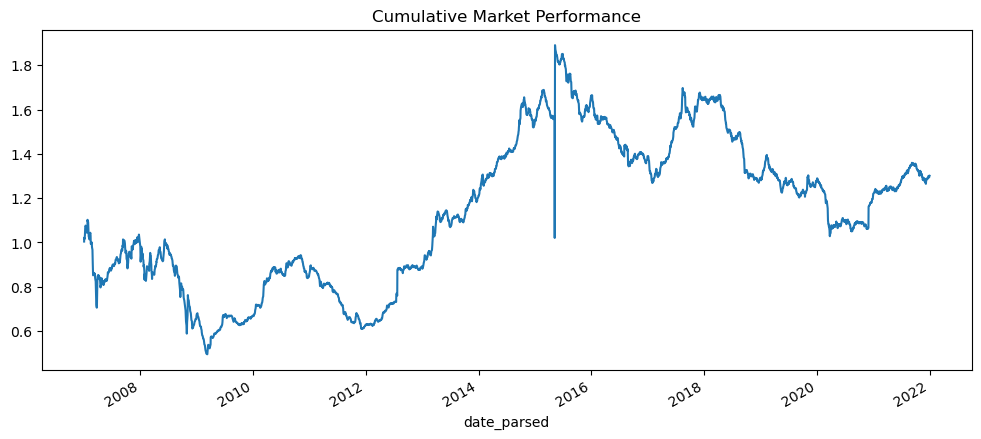

In [59]:
# First ensure sorting
df = cleaning_df.sort_values(['code','date_parsed'])

# Compute returns per stock
df['return'] = df.groupby('code')['day_price'].pct_change()

# Market average return per day
market_return = df.groupby('date_parsed')['return'].mean()

# Market cumulative performance
market_cum = (1+ market_return).cumprod()

# Plotting market cumulative performance
market_cum.plot(figsize= (12,5), title='Cumulative Market Performance');

- The market's performance from 2012 to around 2015 was doing well, however, there was a dip in performance between 2015 and 2016. According to Al Jazeera, the violent lurch lower in stocks was initially triggered by fears that there was an economic slowdown in China, the world's second largest economy. As a result, investors sold shares globally. Additionally, a fall in petroleum prices, the Greek debt default in June 2015, and the effects of the end of quantitative easing in the United States in October 2014 also led to the plunge.

- The stock market continually, did well upto 2020, where it was affected by the COVID-19 virus, but has been recovering since then. We note that there's a steady rise in performance from 2020 to date.

#### *Market Trading Activities*
Here we analysing the trading activities to help us understand the volume trends, market price, how many trades occur per day etc.

##### *Volume Trend*

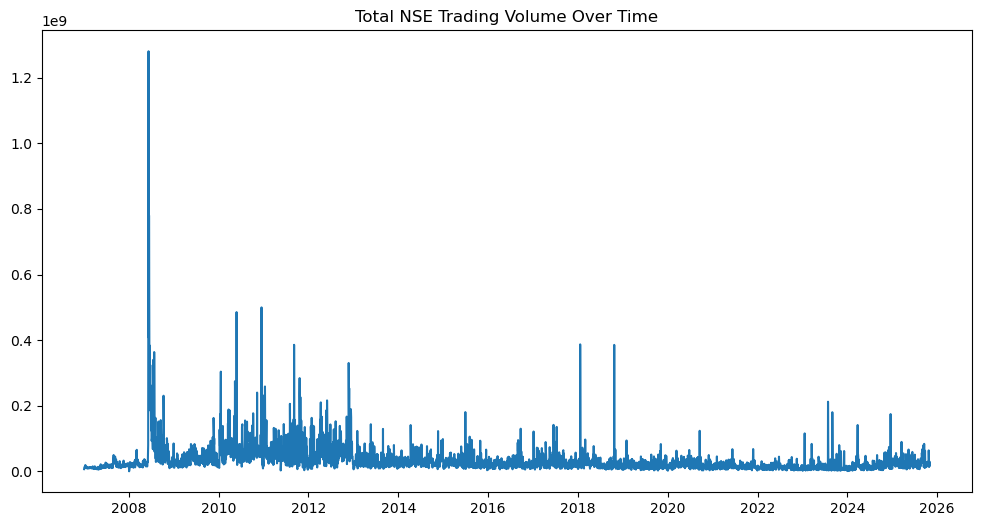

In [61]:
# Market volume over time
market_volume = cleaning_df.groupby('date_parsed')['volume'].sum()

# Plotting 
plt.figure(figsize=(12,6))
plt.plot(market_volume)
plt.title("Total NSE Trading Volume Over Time");

- In the first half of the previous decade, we note thet the volume in the stock market was higher that the first half in the current decade, hinting at the chnages in economies and the markets in general.

- The market was most active from 2008 to about 2018, for almost a decade, and least active from around 2021, after the COVID-19 virus and picked back up towards the end of 2023.

##### *Market Price Over Time*

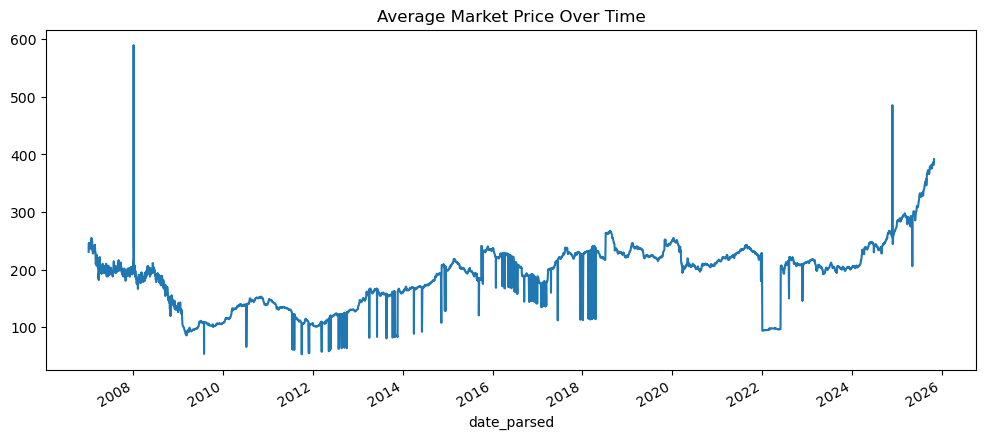

In [62]:
# day_price trend over time
market_trend = cleaning_df.groupby('date_parsed')['day_price'].mean()

# plotting
market_trend.plot(figsize= (12,5), title='Average Market Price Over Time');

- The highest day_price mean was recorded at almost Ksh.600 in 2008, where the lowest was recorded at less that ksh.50 in 2009.

- We note that from around mid-2025, the market price has been on a steady climb from about ksh.300 to around ksh.400.

- Around 2022 towards 2023, there was a plunge in the market price from around ksh.240 to ksh.80, and lasted at least a few months before climbing to around ksh.200.

##### *Number of trades per day*
Analyzing how many trades occurr per day to help us understand if the number of listed companies has been going up or down.

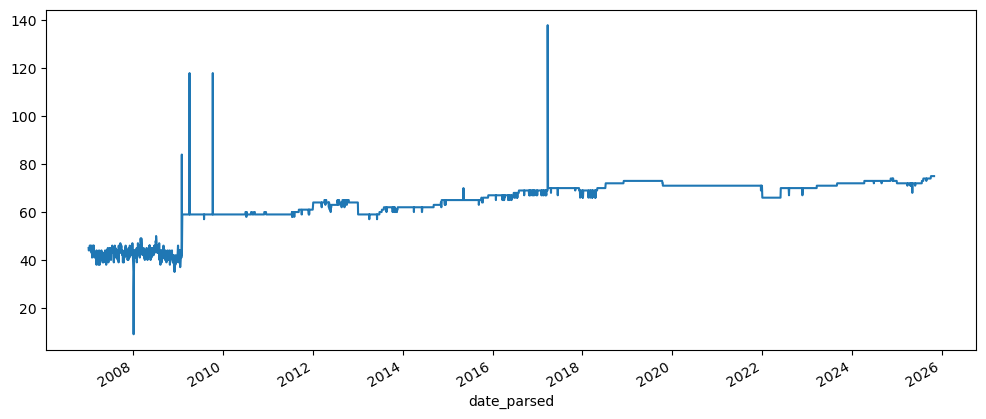

In [63]:
# trades per day
trades = cleaning_df.groupby('date_parsed')['code'].count()

# Plotting
trades.plot(figsize= (12,5));

- There has been a constant rise in the number of trades per day over the years, from sligtly over 40 trades to almost 80 trades. Almost doubling over.

#### *Volume Distribution (Liquidity)*
This helps us understand if the market is liquid or not.

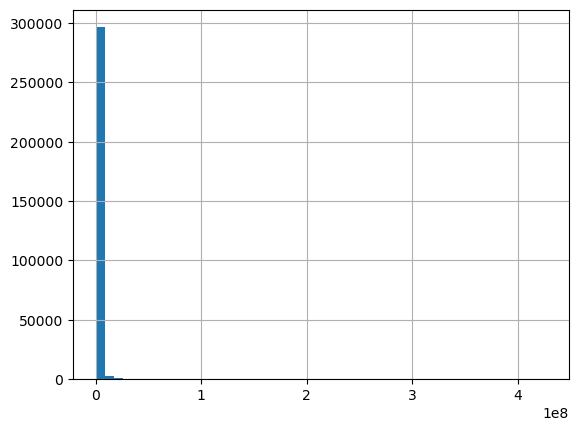

In [67]:
# volume distribution
cleaning_df['volume'].hist(bins= 50);

- The volume distribution is heavily skewed toward lower values, with the majority of trades clustered near zero. This indicates that most stocks in the Nairobi Securities Exchange are relatively illiquid, experiencing low trading activity.

- A small number of observations extend away from 0, suggesting that a few dominant stocks account for the majority of trading activity in the market. This highlights the presence of high concentration in liquidity, where only a handful of stocks drive market activity.

#### *Price Distribution (Market structure)*
This will give us insight into the structure of the market, questioning if most stocks are expensive or cheap.

It will also help us detect outliers.

<Axes: >

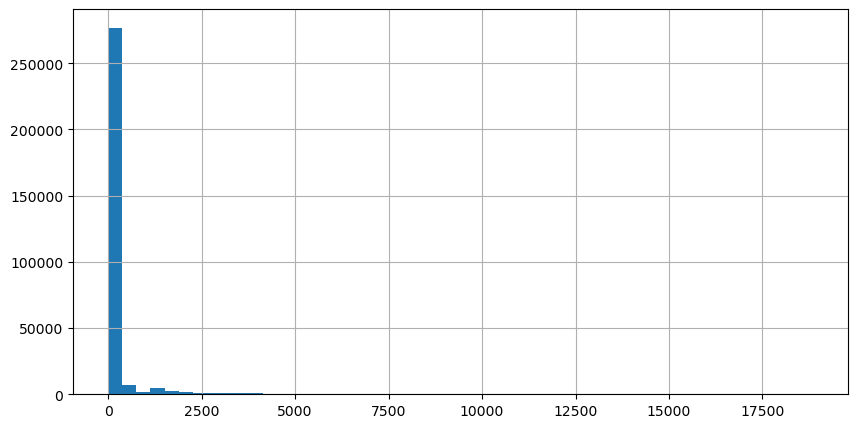

In [ ]:
# price distribution
cleaning_df['day_price'].hist(bins= 50, figsize=(10,5));

- The price distribution shows a strong concentration of stocks at lower price levels, with most observations clustered near zero and a smaller number extending up to approximately 2500 and very few past.

- This indicates that the market is dominated by low-priced stocks, with only a few high-value stocks present. Such a distribution is characteristic of emerging markets, where many listed companies have relatively low share prices, while a few large-cap firms trade at significantly higher values.

#### *Price Movement*

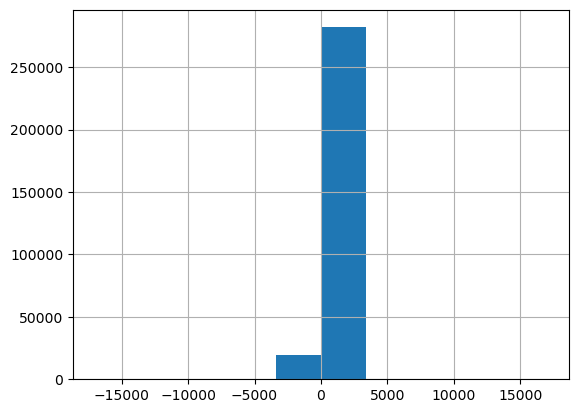

In [69]:
# Price movement
cleaning_df['change'].hist(bins= 10);

- The distribution of price changes is skewed towards positive values, with significantly more observations showing gains than losses. Approximately 290,000 observations fall within the positive range (0 to 3800), compared to fewer than 50,000 in the negative range (-3800 to 0).

- This suggests that, over the observed period, the market exhibited a general upward bias, with stocks more frequently experiencing price increases than declines. This may indicate periods of growth or bullish sentiment within the market.

#### *Correlation Heatmap*
Through this, we seek to understand if prices, volumes and changes correlate with each other.

<Axes: >

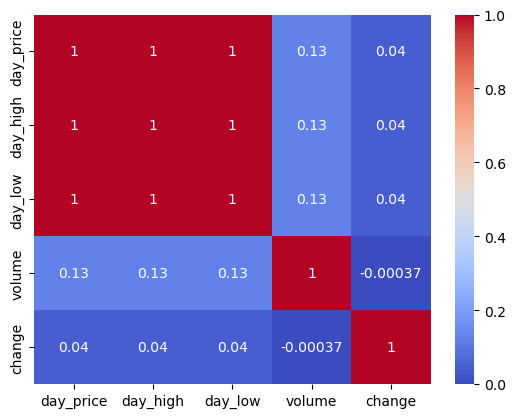

In [ ]:
# Columns we need
cols = ['day_price', 'day_high', 'day_low', 'volume', 'change']

# plot heatmap
sns.heatmap(cleaning_df[cols].corr(), annot= True, cmap='coolwarm')

- `day_price`, `day_low` and `day_high` are positively correlated with each other.

- Whereas the other two columns, `volume` and `change` are negatively correlated with the other columns.

#### *Most traded stocks*
This gives us insight as to which companies dominate the market.

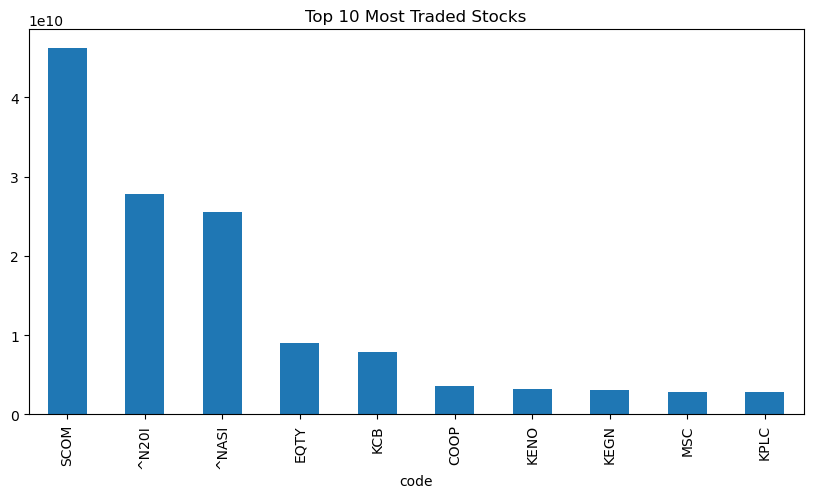

In [ ]:
# Fetching the top traded stocks
top_volume = cleaning_df.groupby('code')['volume'].sum().sort_values(ascending=False).head(10)

# plotting
top_volume.plot(kind= 'bar', figsize= (10,5), title= 'Top 10 Most Traded Stocks');

- Safaricom dominates trading volume, indicating it is the most liquid stock on the exchange.
- The indices also dominate the chart.
- Other dominant companies in the exchange include some of the top kenyan banks, Equity Bank, KCB and Cooperative bank.

#### *Most Volatile Stocks*
This helps us identify the most risky stocks at the exchange.

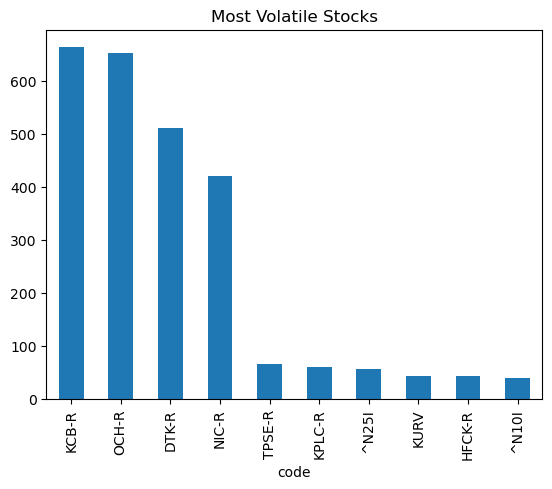

In [74]:
# Fetcing the most volatile stocks
volatility = cleaning_df.groupby('code')['change%'].std().sort_values(ascending= False).head(10)

# Plotting
volatility.plot(kind= 'bar', title= 'Most Volatile Stocks');

- The most volatile stocks in the dataset are predominantly associated with rights issues. These securities tend to exhibit large price fluctuations due to their nature, as they are often issued at discounted prices and are subject to speculative trading.

#### *Top Losers vs Gainers*
Here, we are trying to identify which stocks consistently perform well or poorly.

<Axes: title={'center': 'Top Losers'}, xlabel='code'>

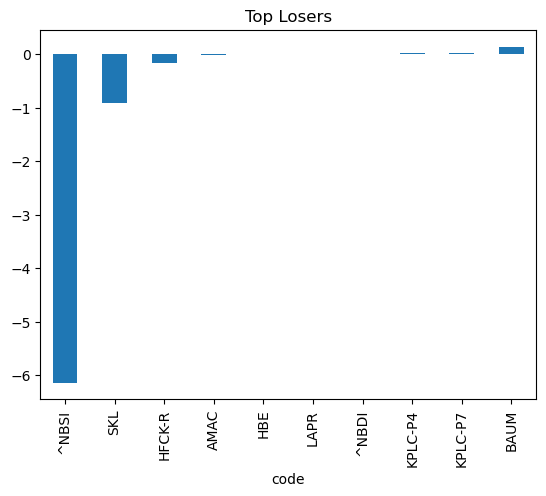

In [ ]:
# plotting top losers
cleaning_df.groupby('code')['change%'].mean().sort_values().head(10).plot(kind='bar', title= 'Top Losers');

- We note that on the plot we have 2 indices, indicating that they are consistently the most losing stocks in the market. This is due to their nature as aggregated measures of market performance. Since they are composed of multiple stocks, abroad decline in constituent stocks leads to a decrease in index value.

<Axes: title={'center': 'Top Gainers'}, xlabel='code'>

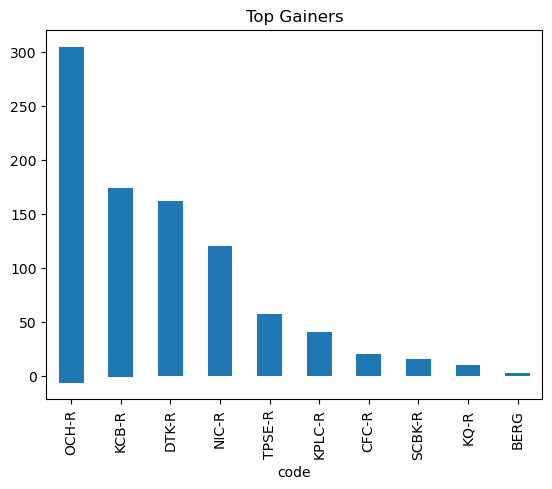

In [ ]:
# Top gainers
cleaning_df.groupby('code')['change%'].mean().sort_values(ascending= False).head(10).plot(kind='bar', title= 'Top Gainers');

- We see that 9 out of ten stocks on the plot are rights issue. In addition to right issue stocks being the most volatile, these same stocks appear among the top gainers, indicating that their high volatility is driven by sharp upward price movements. 
- This suggests that corporate actions such as rights issues significantly influence both volatility and short-term returns in the market.

Overall, the analysis reveals a market characterized by low liquidity for most stocks, a concentration of low-priced securities, and a small number of highly active and influential stocks. Market movements appear to be driven largely by a few dominant players and corporate actions such as rights issues, which contribute significantly to volatility and extreme price changes.

### **Company Level Analysis (Safaricom PLC - SCOM)**
Safaricom officially listed and commenced trading on the Nairobi Securities Exchange (NSE) on June 9, 2008, following a public offering (IPO) of 25% of its shares. The IPO, launched earlier on March 28, 2008, was a landmark, offering 10 billion shares at Kshs 5.0 each and increasing total market capitalization. 

In [80]:
safaricom = cleaning_df[cleaning_df['code'] == 'SCOM']

In [81]:
safaricom.head(15)

,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price,date_parsed,range_12m
13897,SCOM,Safaricom,3.10,6.6,5.00,5.00,5.00,29.75,-24.75,495.00,0.0,-,2008-04-23,3.50
15243,SCOM,Safaricom,3.10,6.6,6.95,8.00,7.35,5.00,2.35,31.97,416380000.0,-,2008-06-09,3.50
15285,SCOM,Safaricom,3.10,6.6,6.65,8.00,6.95,7.35,-0.40,5.76,127310000.0,-,2008-06-10,3.50
15330,SCOM,Safaricom,3.10,6.6,6.90,7.10,6.95,6.95,0.00,0.00,183490000.0,-,2008-06-11,3.50
15374,SCOM,Safaricom,3.10,6.6,7.10,7.50,7.35,6.95,0.40,5.44,131240000.0,-,2008-06-12,3.50
15419,SCOM,Safaricom,3.10,6.6,7.00,7.65,7.45,7.35,0.10,1.34,250900000.0,-,2008-06-13,3.50
15461,SCOM,Safaricom,3.10,6.6,7.50,8.15,7.90,7.45,0.45,5.70,103790000.0,-,2008-06-16,3.50
15504,SCOM,Safaricom,3.10,6.6,7.70,8.05,7.80,7.90,-0.10,1.28,121490000.0,-,2008-06-17,3.50
15547,SCOM,Safaricom,3.10,6.6,7.70,7.90,7.80,7.80,0.00,0.00,112660000.0,-,2008-06-18,3.50
15591,SCOM,Safaricom,3.10,6.6,7.80,7.90,7.85,7.80,0.05,0.64,58890000.0,-,2008-06-19,3.50


In [82]:
safaricom.tail(20)

,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price,date_parsed,range_12m
299571,SCOM,Safaricom Plc,14.1,31.0,28.90,29.45,29.30,28.90,0.40,1.38,6186814.0,-,2025-10-01,16.9
299645,SCOM,Safaricom Plc,14.1,31.0,28.95,29.50,29.35,29.30,0.05,0.17,7453413.0,-,2025-10-02,16.9
299719,SCOM,Safaricom Plc,14.1,31.0,28.80,29.20,28.90,29.35,-0.45,-1.53,1436320.0,-,2025-10-03,16.9
299793,SCOM,Safaricom Plc,14.1,31.0,28.25,29.00,28.65,28.90,-0.25,-0.87,598377.0,-,2025-10-06,16.9
299868,SCOM,Safaricom Plc,14.1,31.0,27.45,28.90,28.20,28.65,-0.45,-1.57,5131599.0,-,2025-10-07,16.9
299943,SCOM,Safaricom Plc,14.1,31.0,27.20,28.00,27.40,28.20,-0.80,-2.84,8525973.0,-,2025-10-08,16.9
300018,SCOM,Safaricom Plc,14.1,31.0,26.65,27.45,27.10,27.40,-0.30,-1.09,4492292.0,-,2025-10-09,16.9
300093,SCOM,Safaricom Plc,14.1,31.0,26.10,27.35,26.60,27.10,-0.50,-1.85,3919201.0,-,2025-10-13,16.9
300168,SCOM,Safaricom Plc,14.1,31.0,25.80,26.50,26.00,26.60,-0.60,-2.26,2540959.0,-,2025-10-14,16.9
300243,SCOM,Safaricom Plc,14.1,31.0,26.00,27.50,26.55,26.00,0.55,2.12,6905767.0,-,2025-10-15,16.9


In [83]:
safaricom.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4335 entries, 13897 to 300993
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   code            4335 non-null   object        
 1   name            4335 non-null   object        
 2   12m_low         4335 non-null   float64       
 3   12m_high        4335 non-null   float64       
 4   day_low         4335 non-null   float64       
 5   day_high        4335 non-null   float64       
 6   day_price       4335 non-null   float64       
 7   previous        4335 non-null   float64       
 8   change          4335 non-null   float64       
 9   change%         4335 non-null   float64       
 10  volume          4335 non-null   float64       
 11  adjusted_price  4335 non-null   object        
 12  date_parsed     4335 non-null   datetime64[ns]
 13  range_12m       4335 non-null   float64       
dtypes: datetime64[ns](1), float64(10), object(3)
memory usa

In [84]:
safaricom.describe()

,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,date_parsed,range_12m
count,4335.000000,4335.000000,4335.000000,4335.000000,4335.000000,4335.000000,4335.000000,4335.000000,4.335000e+03,4335,4335.000000
mean,16.451396,25.344602,17.092537,17.578685,17.298627,17.299193,-0.000565,1.054268,1.066320e+07,2017-02-09 00:35:32.595155712,8.893206
min,3.050000,6.500000,2.500000,2.700000,2.550000,2.550000,-24.750000,-9.860000,0.000000e+00,2008-04-23 00:00:00,3.450000
25%,3.100000,6.600000,5.600000,5.850000,5.750000,5.750000,-0.100000,0.000000,3.266900e+06,2012-10-01 12:00:00,3.500000
50%,23.500000,33.500000,16.100000,16.600000,16.350000,16.350000,0.000000,0.710000,6.838100e+06,2017-02-03 00:00:00,10.000000
75%,23.500000,33.500000,26.500000,27.200000,26.750000,26.750000,0.100000,1.520000,1.279535e+07,2021-06-15 12:00:00,10.000000
max,34.000000,45.250000,44.000000,45.250000,44.950000,44.950000,2.350000,495.000000,4.163800e+08,2025-10-31 00:00:00,19.750000
std,9.359510,12.545014,10.876263,11.132814,10.996043,10.996423,0.499871,7.659183,1.500578e+07,NaN,3.817101


In [ ]:
safaricom.set_index('date_parsed')['day_price'].plot(figsize= (12,5), title= 'Safaricom Price Over Time')

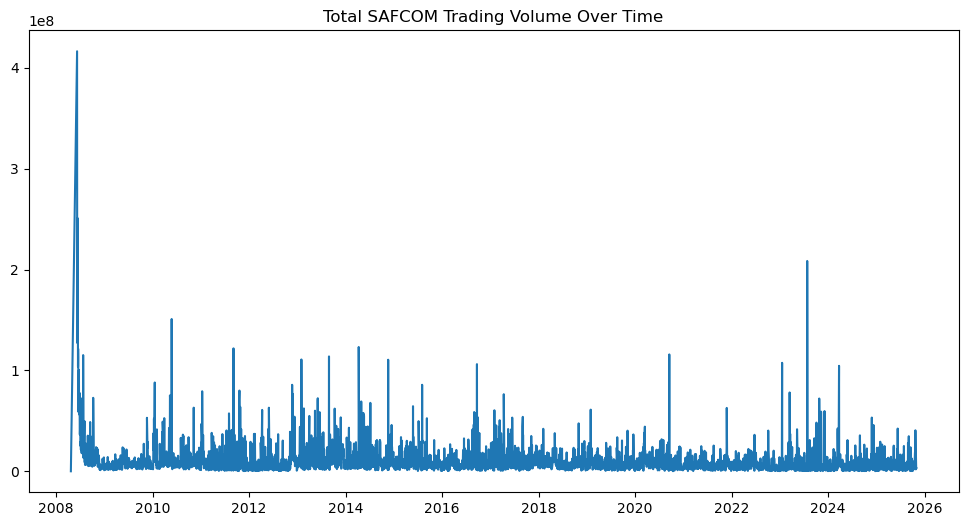

In [85]:
market_volume = safaricom.groupby('date_parsed')['volume'].sum()

plt.figure(figsize=(12,6))
plt.plot(market_volume)
plt.title("Total SAFCOM Trading Volume Over Time");

<Axes: >

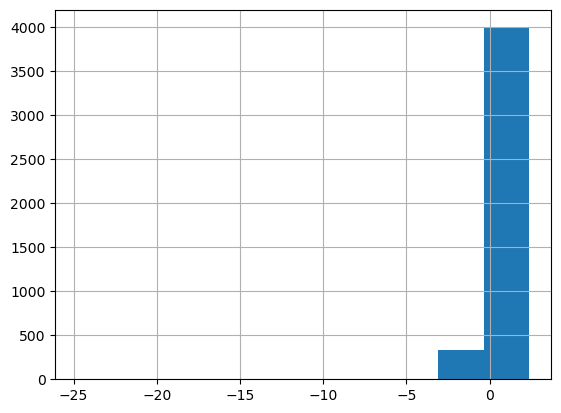

In [86]:
safaricom['change'].hist(bins= 10)

<Axes: >

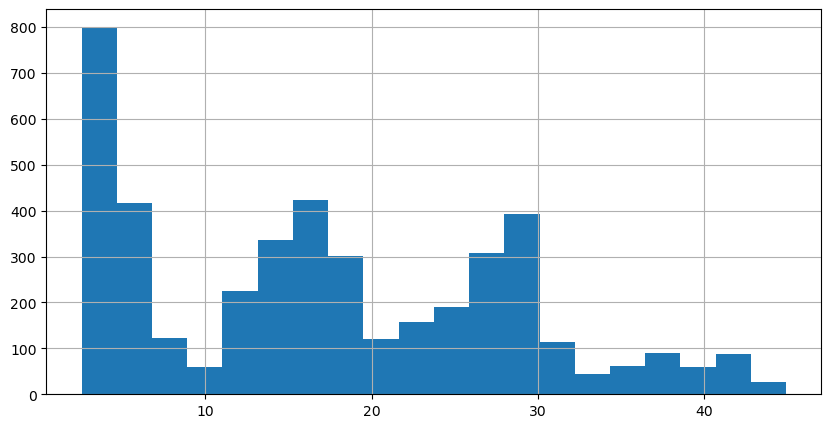

In [87]:
safaricom['day_price'].hist(bins= 20, figsize=(10,5))

<Axes: xlabel='range_12m', ylabel='Count'>

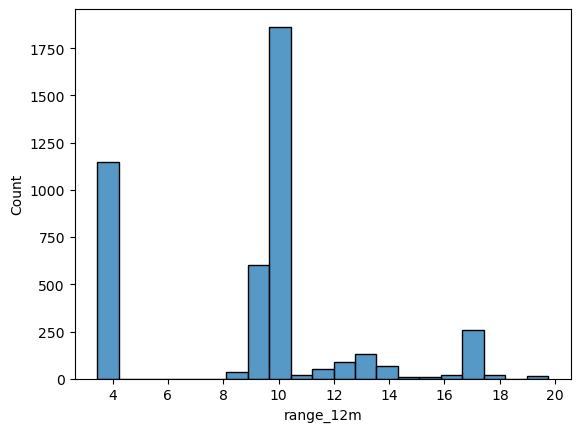

In [88]:
sns.histplot(safaricom['range_12m'])

<Axes: xlabel='day_low', ylabel='day_high'>

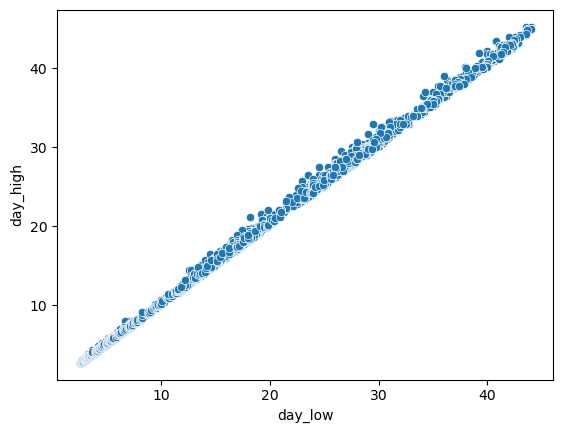

In [89]:
sns.scatterplot(data= safaricom, x= 'day_low', y= 'day_high')

<Axes: >

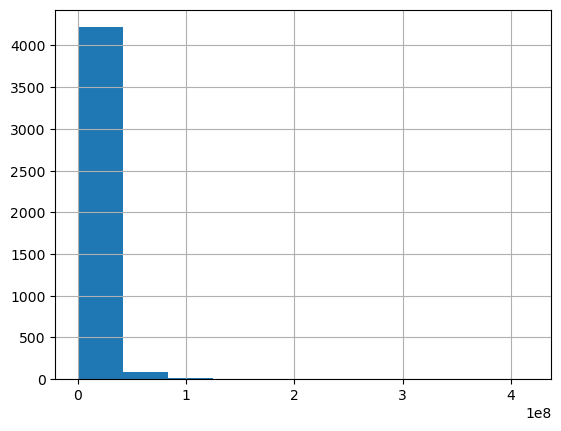

In [91]:
safaricom['volume'].hist(bins= 10)

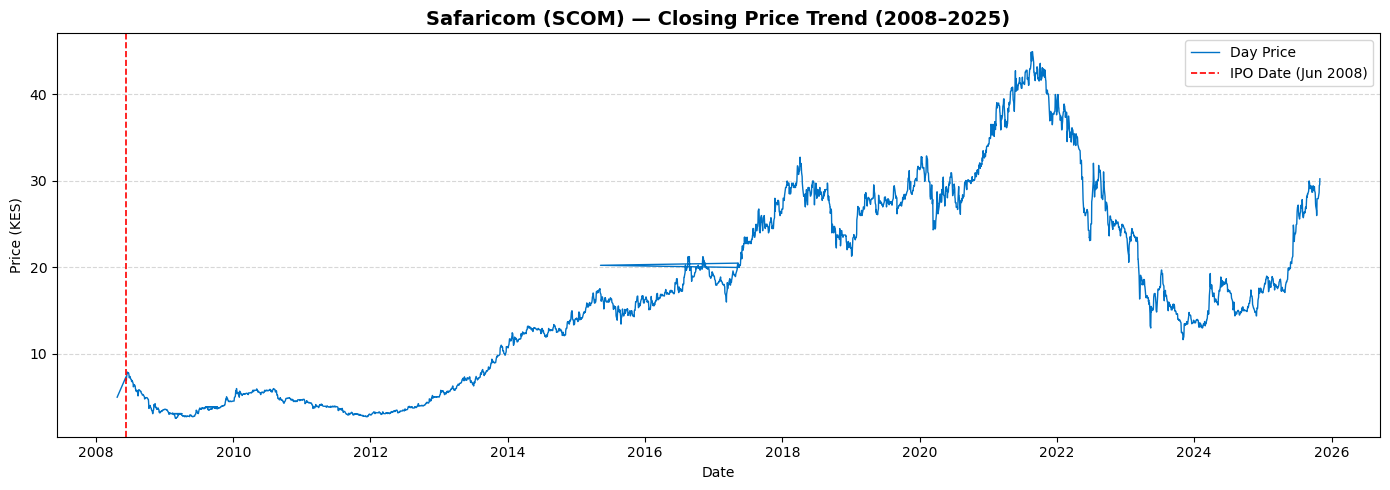

In [ ]:
# Safaricom: Closing Price Trend Over Time
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(safaricom['date_parsed'], safaricom['day_price'], 
        color='#0072C6', linewidth=1, label='Day Price')

# Mark the IPO date as a reference point
ipo_date = pd.Timestamp('2008-06-09')
ax.axvline(x=ipo_date, color='red', linestyle='--', linewidth=1.2, label='IPO Date (Jun 2008)')

ax.set_title('Safaricom (SCOM) — Closing Price Trend (2008–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (KES)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

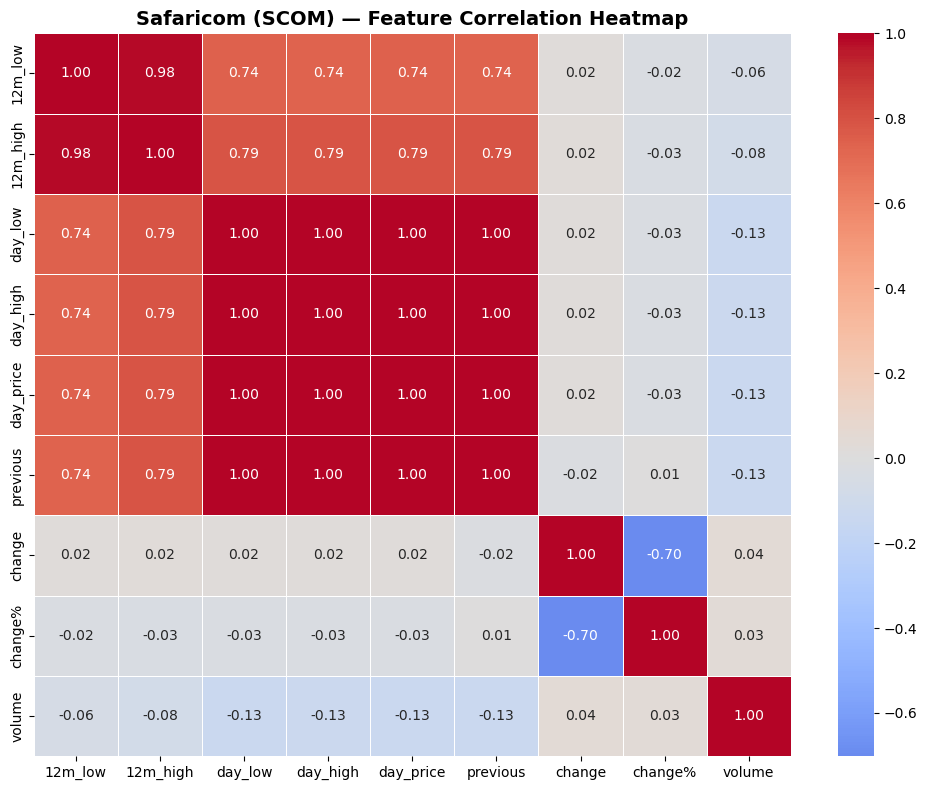

In [ ]:
# Safaricom: Correlation Heatmap
# Select only numeric columns for the heatmap
scom_numeric = safaricom[['12m_low', '12m_high', 'day_low', 'day_high', 
                           'day_price', 'previous', 'change', 'change%', 'volume']]

corr_matrix = scom_numeric.corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            linewidths=0.5,
            ax=ax)

ax.set_title('Safaricom (SCOM) — Feature Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

- The heatmap shows how strongly the numeric columns move together. For modelling, we want to understand:
    - Which features are highly correlated with day_price (target)
    - Which features are correlated with each other (multicollinearity)
    - important for linear models.


##  **Feature Engineering**

Based on our EDA findings, we now engineer features that will be used to predict
the **next-day closing price** of a stock (`target: next_day_close`).

The features we build fall into four categories:

| Category | Features | Why |
|---|---|---|
| **Target** | `next_day_close` | What we are predicting |
| **Lag features** | `lag_1` to `lag_7` | Yesterday's price is the strongest predictor of today's |
| **Rolling averages** | `ma_7`, `ma_30` | Capture short and medium-term trend direction |
| **Return & Volatility** | `daily_return`, `volatility_7`, `volatility_30` | Capture momentum and risk |
| **Price range** | `day_range`, `range_position` | Capture intraday buying/selling pressure |


> All features are computed **per stock** using `groupby('code')` to prevent
> data leakage between different companies.

- Exclude the features starting with (^) as they are not tradable 

In [92]:
# Work on a clean copy so cleaning_df stays untouched
features_df = cleaning_df[~cleaning_df['code'].str.startswith('^')].copy()

# Sort by stock code and date — critical for correct lag/rolling calculations
features_df = features_df.sort_values(['code', 'date_parsed']).reset_index(drop=True)


In [93]:
features_df

,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,volume,adjusted_price,date_parsed,range_12m
0,ABSA,ABSA Bank Kenya Plc,9.3,14.2,15.65,16.0,15.7,15.75,-0.05,0.32,78200.0,-,2013-01-02,4.9
1,ABSA,ABSA Bank Kenya Plc,9.3,14.2,15.65,16.0,15.7,15.75,-0.05,0.32,78200.0,-,2013-01-02,4.9
2,ABSA,ABSA Bank Kenya Plc,9.3,14.2,15.65,16.0,15.7,15.75,-0.05,0.32,78200.0,-,2013-01-02,4.9
3,ABSA,ABSA Bank Kenya Plc,9.3,14.2,15.65,16.0,15.7,15.75,-0.05,0.32,78200.0,-,2013-01-02,4.9
4,ABSA,ABSA Bank Kenya Plc,9.3,14.2,15.65,16.0,15.7,15.75,-0.05,0.32,78200.0,-,2013-01-02,4.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1405640,XPRS,Express Kenya Plc,2.8,10.0,6.90,7.4,6.9,7.38,-0.48,-6.50,3210.0,-,2025-10-31,7.2
1405641,XPRS,Express Kenya Plc,2.8,10.0,6.90,7.4,6.9,7.38,-0.48,-6.50,3210.0,-,2025-10-31,7.2
1405642,XPRS,Express Kenya Plc,2.8,10.0,6.90,7.4,6.9,7.38,-0.48,-6.50,3210.0,-,2025-10-31,7.2
1405643,XPRS,Express Kenya Plc,2.8,10.0,6.90,7.4,6.9,7.38,-0.48,-6.50,3210.0,-,2025-10-31,7.2



1. TARGET VARIABLE
 - next_day_close: the closing price of the NEXT trading day.
 - We shift day_price by -1 within each stock group.
 - The last row per stock will be NaN (no future price exists)  and will be dropped later.

In [94]:
features_df['next_day_close'] = features_df.groupby('code')['day_price'].shift(-1)

2. LAG FEATURES
 - Lag features give the model "memory" of recent prices.
 - lag_1 = yesterday's close, lag_2 = 2 days ago, etc.
 - These are the most predictive features for any price model.


In [95]:
for lag in [1, 2, 3, 5, 7]:
    features_df[f'lag_{lag}'] = features_df.groupby('code')['day_price'].shift(lag)

3. ROLLING AVERAGES (MA7, MA30)

 - MA7 captures short-term price momentum (one trading week).
 - MA30 captures medium-term trend (roughly one trading month).
 - min_periods=1 avoids NaN at the very start of a stock's history.


In [96]:
features_df['ma_7'] = (
    features_df.groupby('code')['day_price']
    .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
)

features_df['ma_30'] = (
    features_df.groupby('code')['day_price']
    .transform(lambda x: x.rolling(window=30, min_periods=1).mean())
)



4. DAILY RETURN & ROLLING VOLATILITY

 - daily_return: percentage change from previous close to today's close. - This normalizes price movements across stocks of different price levels.

 - volatility_7 / volatility_30: rolling standard deviation of daily returns. - This captures how "risky" or erratic a stock has been recently — an important signal that models can use to adjust their predictions.


In [97]:
features_df['daily_return'] = (
    features_df.groupby('code')['day_price']
    .transform(lambda x: x.pct_change())
)

features_df['volatility_7'] = (
    features_df.groupby('code')['daily_return']
    .transform(lambda x: x.rolling(window=7, min_periods=1).std())
)

features_df['volatility_30'] = (
    features_df.groupby('code')['daily_return']
    .transform(lambda x: x.rolling(window=30, min_periods=1).std())
)

5. PRICE RANGE FEATURES
 - day_range: the full intraday price swing (high - low).- A wide range signals high volatility on that specific day.

 - range_position: where the closing price sits within the day's range. - A value close to 1.0 means the stock closed near its daily high (bullish signal). A value close to 0.0 means it closed near the daily low (bearish signal).

We add a small epsilon (1e-9) to avoid division by zero on flat days.


In [98]:
features_df['day_range'] = features_df['day_high'] - features_df['day_low']

features_df['range_position'] = (
    (features_df['day_price'] - features_df['day_low']) / 
    (features_df['day_range'] + 1e-9)
)

print("Features created successfully.")
print(f"Shape before dropping NaNs: {features_df.shape}")

Features created successfully.
Shape before dropping NaNs: (1405645, 27)


In [102]:
features_df

,code,name,12m_low,12m_high,day_low,day_high,day_price,previous,change,change%,...,lag_3,lag_5,lag_7,ma_7,ma_30,daily_return,volatility_7,volatility_30,day_range,range_position
0,ABSA,ABSA Bank Kenya Plc,9.0,14.2,15.7,16.0,15.80,15.70,0.10,0.64,...,15.70,15.70,15.70,15.742857,15.737500,0.000000,0.002407,0.002407,0.3,0.333333
1,ABSA,ABSA Bank Kenya Plc,9.0,14.2,15.7,16.0,15.80,15.70,0.10,0.64,...,15.80,15.70,15.70,15.757143,15.744444,0.000000,0.002407,0.002252,0.3,0.333333
2,ABSA,ABSA Bank Kenya Plc,9.0,14.2,15.7,16.0,15.80,15.70,0.10,0.64,...,15.80,15.70,15.70,15.771429,15.750000,0.000000,0.002407,0.002123,0.3,0.333333
3,ABSA,ABSA Bank Kenya Plc,9.0,14.2,15.7,16.0,15.75,15.80,-0.05,0.32,...,15.80,15.80,15.70,15.778571,15.750000,-0.003165,0.002861,0.002347,0.3,0.166667
4,ABSA,ABSA Bank Kenya Plc,9.0,14.2,15.7,16.0,15.75,15.80,-0.05,0.32,...,15.80,15.80,15.70,15.785714,15.750000,0.000000,0.002861,0.002228,0.3,0.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1404868,XPRS,Express Kenya Plc,2.8,10.0,6.9,7.4,7.38,6.80,0.58,8.53,...,7.38,6.80,6.80,7.214286,7.043333,0.000000,0.032238,0.016865,0.5,0.960000
1404869,XPRS,Express Kenya Plc,2.8,10.0,6.9,7.4,6.90,7.38,-0.48,-6.50,...,7.38,7.38,6.80,7.228571,7.039333,-0.065041,0.043678,0.020630,0.5,0.000000
1404870,XPRS,Express Kenya Plc,2.8,10.0,6.9,7.4,6.90,7.38,-0.48,-6.50,...,7.38,7.38,6.80,7.242857,7.035333,0.000000,0.043678,0.020630,0.5,0.000000
1404871,XPRS,Express Kenya Plc,2.8,10.0,6.9,7.4,6.90,7.38,-0.48,-6.50,...,7.38,7.38,7.38,7.174286,7.031333,0.000000,0.024583,0.020630,0.5,0.000000


- Drop rows with NaN in critical feature/target columns because Lag features create NaN for the first N rows of each stock (e.g., lag_7 needs 7 prior rows before it has a value).
- The target also creates NaN for the LAST row of each stock.

In [100]:
# Columns that must not be NaN for training
critical_cols = ['next_day_close', 'lag_1', 'lag_2', 'lag_3', 
                 'lag_5', 'lag_7', 'ma_7', 'ma_30',
                 'daily_return', 'volatility_7', 'volatility_30',
                 'day_range', 'range_position']

features_df = features_df.dropna(subset=critical_cols).reset_index(drop=True)

print(f"Shape after dropping NaNs: {features_df.shape}")
print(f"Unique stocks remaining: {features_df['code'].nunique()}")

Shape after dropping NaNs: (1404873, 27)
Unique stocks remaining: 96


In [103]:
# Inspect the final feature columns and a sample

feature_cols = ['date_parsed', 'code', 'name', 'day_price', 'next_day_close',
                'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_7',
                'ma_7', 'ma_30', 'daily_return', 'volatility_7', 
                'volatility_30', 'day_range', 'range_position', 'volume']

print("Final feature columns:")
print(feature_cols)
print()

features_df[feature_cols].head(10)

Final feature columns:
['date_parsed', 'code', 'name', 'day_price', 'next_day_close', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_7', 'ma_7', 'ma_30', 'daily_return', 'volatility_7', 'volatility_30', 'day_range', 'range_position', 'volume']



,date_parsed,code,name,day_price,next_day_close,lag_1,lag_2,lag_3,lag_5,lag_7,ma_7,ma_30,daily_return,volatility_7,volatility_30,day_range,range_position,volume
0,2013-01-03,ABSA,ABSA Bank Kenya Plc,15.80,15.80,15.80,15.80,15.70,15.70,15.7,15.742857,15.737500,0.000000,0.002407,0.002407,0.30,0.333333,97900.0
1,2013-01-03,ABSA,ABSA Bank Kenya Plc,15.80,15.80,15.80,15.80,15.80,15.70,15.7,15.757143,15.744444,0.000000,0.002407,0.002252,0.30,0.333333,97900.0
2,2013-01-03,ABSA,ABSA Bank Kenya Plc,15.80,15.75,15.80,15.80,15.80,15.70,15.7,15.771429,15.750000,0.000000,0.002407,0.002123,0.30,0.333333,97900.0
3,2013-01-04,ABSA,ABSA Bank Kenya Plc,15.75,15.75,15.80,15.80,15.80,15.80,15.7,15.778571,15.750000,-0.003165,0.002861,0.002347,0.30,0.166667,391900.0
4,2013-01-04,ABSA,ABSA Bank Kenya Plc,15.75,15.75,15.75,15.80,15.80,15.80,15.7,15.785714,15.750000,0.000000,0.002861,0.002228,0.30,0.166667,391900.0
5,2013-01-04,ABSA,ABSA Bank Kenya Plc,15.75,15.75,15.75,15.75,15.80,15.80,15.8,15.778571,15.750000,0.000000,0.001196,0.002126,0.30,0.166667,391900.0
6,2013-01-04,ABSA,ABSA Bank Kenya Plc,15.75,15.75,15.75,15.75,15.75,15.80,15.8,15.771429,15.750000,0.000000,0.001196,0.002037,0.30,0.166667,391900.0
7,2013-01-04,ABSA,ABSA Bank Kenya Plc,15.75,15.70,15.75,15.75,15.75,15.80,15.8,15.764286,15.750000,0.000000,0.001196,0.001958,0.30,0.166667,391900.0
8,2013-01-07,ABSA,ABSA Bank Kenya Plc,15.70,15.70,15.75,15.75,15.75,15.75,15.8,15.750000,15.746875,-0.003175,0.001547,0.002082,0.25,0.000000,246400.0
9,2013-01-07,ABSA,ABSA Bank Kenya Plc,15.70,15.70,15.70,15.75,15.75,15.75,15.8,15.735714,15.744118,0.000000,0.001547,0.002011,0.25,0.000000,246400.0


In [104]:
# Extract Safaricom subset for focused modelling


scom_fe = features_df[features_df['code'] == 'SCOM'][feature_cols].reset_index(drop=True)

print(f"Safaricom feature rows: {scom_fe.shape[0]}")
print(f"Date range: {scom_fe['date_parsed'].min()} → {scom_fe['date_parsed'].max()}")
print()
scom_fe.head()

Safaricom feature rows: 21667
Date range: 2008-06-09 00:00:00 → 2025-10-31 00:00:00



,date_parsed,code,name,day_price,next_day_close,lag_1,lag_2,lag_3,lag_5,lag_7,ma_7,ma_30,daily_return,volatility_7,volatility_30,day_range,range_position,volume
0,2008-06-09,SCOM,Safaricom,7.35,7.35,7.35,7.35,5.00,5.00,5.0,6.007143,5.881250,0.000000,0.177643,0.177643,1.05,0.380952,416380000.0
1,2008-06-09,SCOM,Safaricom,7.35,7.35,7.35,7.35,7.35,5.00,5.0,6.342857,6.044444,0.000000,0.177643,0.166170,1.05,0.380952,416380000.0
2,2008-06-09,SCOM,Safaricom,7.35,6.95,7.35,7.35,7.35,5.00,5.0,6.678571,6.175000,0.000000,0.177643,0.156667,1.05,0.380952,416380000.0
3,2008-06-10,SCOM,Safaricom,6.95,6.95,7.35,7.35,7.35,7.35,5.0,6.957143,6.245455,-0.054422,0.182204,0.151508,1.35,0.222222,127310000.0
4,2008-06-10,SCOM,Safaricom,6.95,6.95,6.95,7.35,7.35,7.35,5.0,7.235714,6.304167,0.000000,0.182204,0.144278,1.35,0.222222,127310000.0


In [105]:
# Save feature-engineered datasets to processed folder

#   1. scom_features.csv       — Safaricom only (for primary modelling)
#   2. all_stocks_features.csv — Full NSE dataset (for multi-stock extension)

features_df[feature_cols].to_csv("../data/raw_data/processed/all_stocks_features.csv", index=False)
scom_fe.to_csv("../data/raw_data/processed/scom_features.csv", index=False)

print("Saved: all_stocks_features.csv")
print("Saved: scom_features.csv")

Saved: all_stocks_features.csv
Saved: scom_features.csv


### 4.1 Feature Engineering Summary

| Feature | Type | Notes |
|---|---|---|
| `next_day_close` | Target | Shift(-1) per stock group |
| `lag_1` → `lag_7` | Lag | Price memory - strongest predictors |
| `ma_7`, `ma_30` | Rolling mean | Short & medium-term trend |
| `daily_return` | Derived | % change from previous close |
| `volatility_7`, `volatility_30` | Rolling std | Recent risk signal |
| `day_range` | Derived | Intraday high - low spread |
| `range_position` | Derived | Close position within day range (0–1) |

